# Find alpha DSE1-4

May 4, 2025 - An attempt to reproduce the find alpha parameter using the DSE genes. The differences in the replicate fits and the shorter delta values make this procedure difficult to reliably reproduce consistently across both replicates. Replicate 1 produces very long alphas > 28, replicate 2 produces very short ones < 8. Whereas we would expect values between 12-20 proportionally to the length of the cell cycle as per Xin Guo's work.


In [233]:
# Preamble, notebook setup and imports

%load_ext autoreload
%autoreload 2
%matplotlib inline
%config InlineBackend.figure_format = 'retina'

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [249]:
from pipeline.CombinedDeconvolveGeneExpressionRunner import CombinedDeconvolveGeneExpressionRunner
output_directory = 'output/draft3_run/'
runner = CombinedDeconvolveGeneExpressionRunner(output_directory, False)

In [250]:
runner.config1.modify_alpha(30)

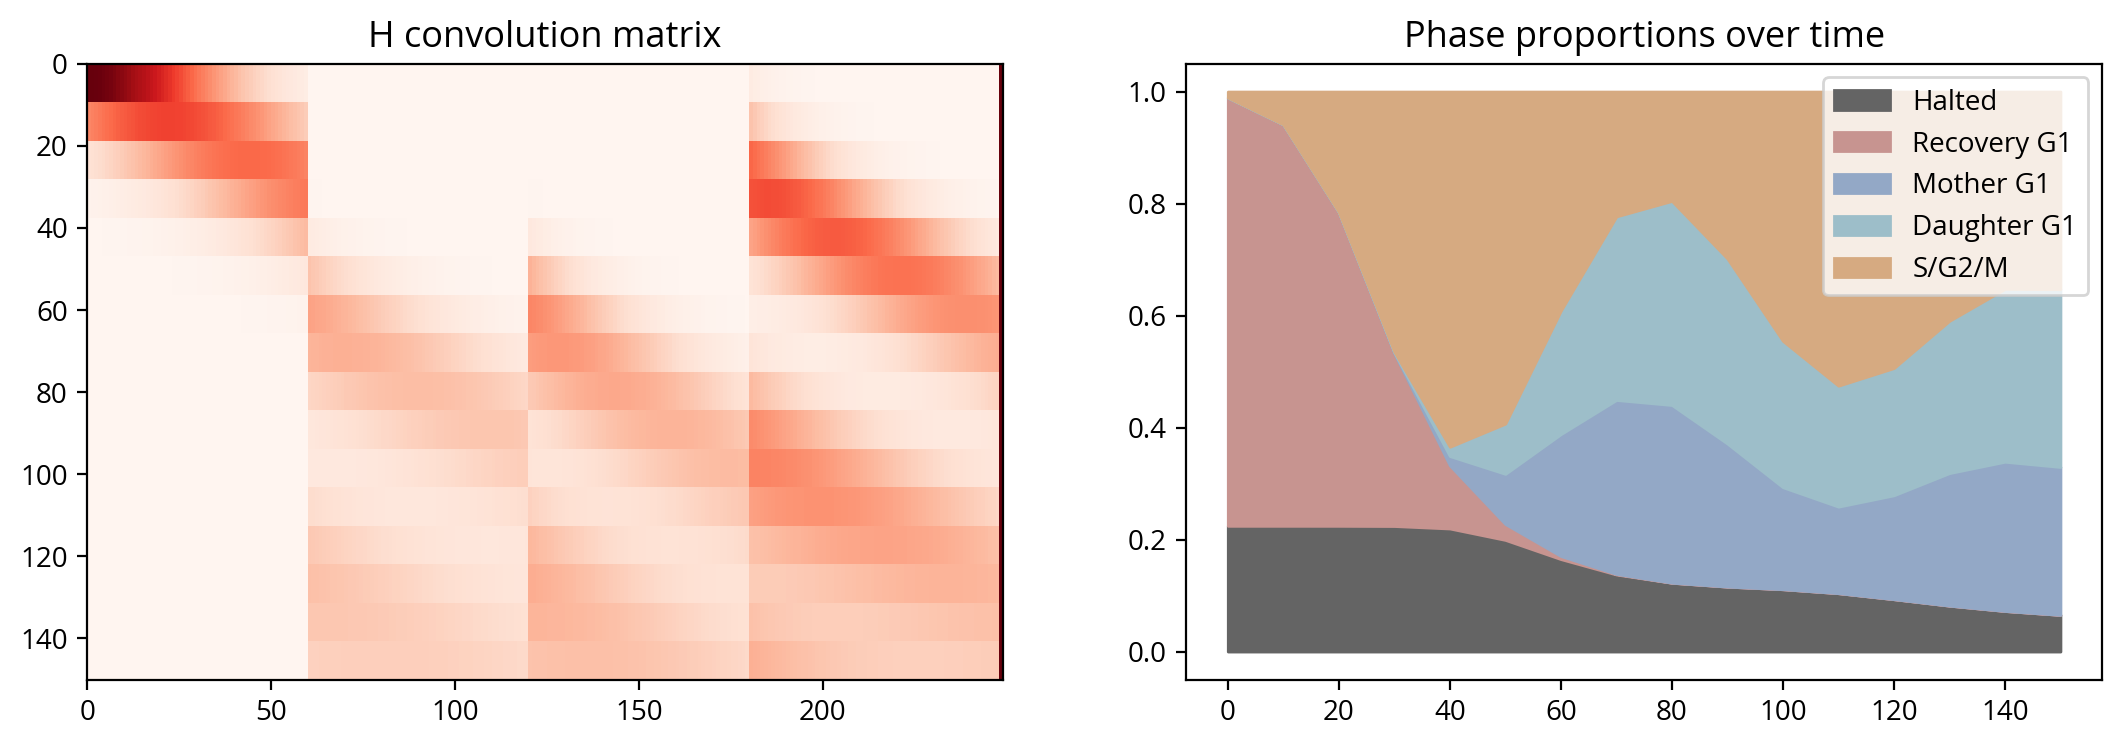

In [251]:
runner.config1.plot_H()

In [252]:
runner.deconvolve_gene_find_gamma('DSE3', replicate=1, verbose=True)

	Base error (γ=0):	rn: 0.436989	sn: 11448.810583
	Error boundaries:
		Left:
			Relative (1.05 * e0): 0.458838
			Absolute (e0 + 0.04): 0.476989
			Chosen: 0.458838
		Right:
			Relative (4.00 * e0): 1.74796
			Absolute (e0 + 11.32): 11.757
			Chosen: 11.756989
	Searching for left boundary gamma...
		γ: 0.5005	rn: 19.1748	sn: 70.6041
		γ: 0.25075	rn: 14.4910	sn: 84.1294
		γ: 0.125875	rn: 10.3989	sn: 106.2775
		γ: 0.0634375	rn: 4.8266	sn: 170.1685
		γ: 0.0322187	rn: 2.7185	sn: 214.2448
		γ: 0.0166094	rn: 1.9550	sn: 247.0134
		γ: 0.00880469	rn: 1.5021	sn: 286.6395
		γ: 0.00490234	rn: 1.2063	sn: 329.4374
		γ: 0.00295117	rn: 1.1197	sn: 354.6241
		γ: 0.00197559	rn: 1.0511	sn: 380.4358
		γ: 0.00148779	rn: 0.9203	sn: 456.4013
		γ: 0.0012439	rn: 0.8711	sn: 492.4317
		γ: 0.00112195	rn: 0.8453	sn: 514.1660
		γ: 0.00106097	rn: 0.8429	sn: 516.3426
		γ: 0.00103049	rn: 0.8418	sn: 517.4281
		γ: 0.00101524	rn: 0.8413	sn: 517.8610
		γ: 0.00100762	rn: 0.8411	sn: 518.0461
		γ: 0.00100381	rn: 0.8410	sn: 518

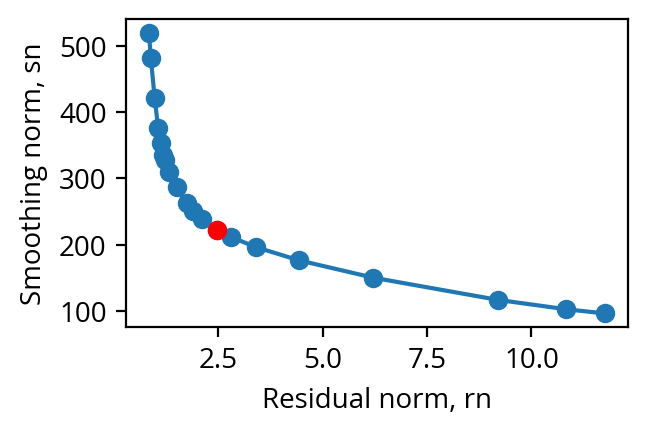

In [253]:
runner.expression_find_gamma.gamma_optimizer.plot_elbow()

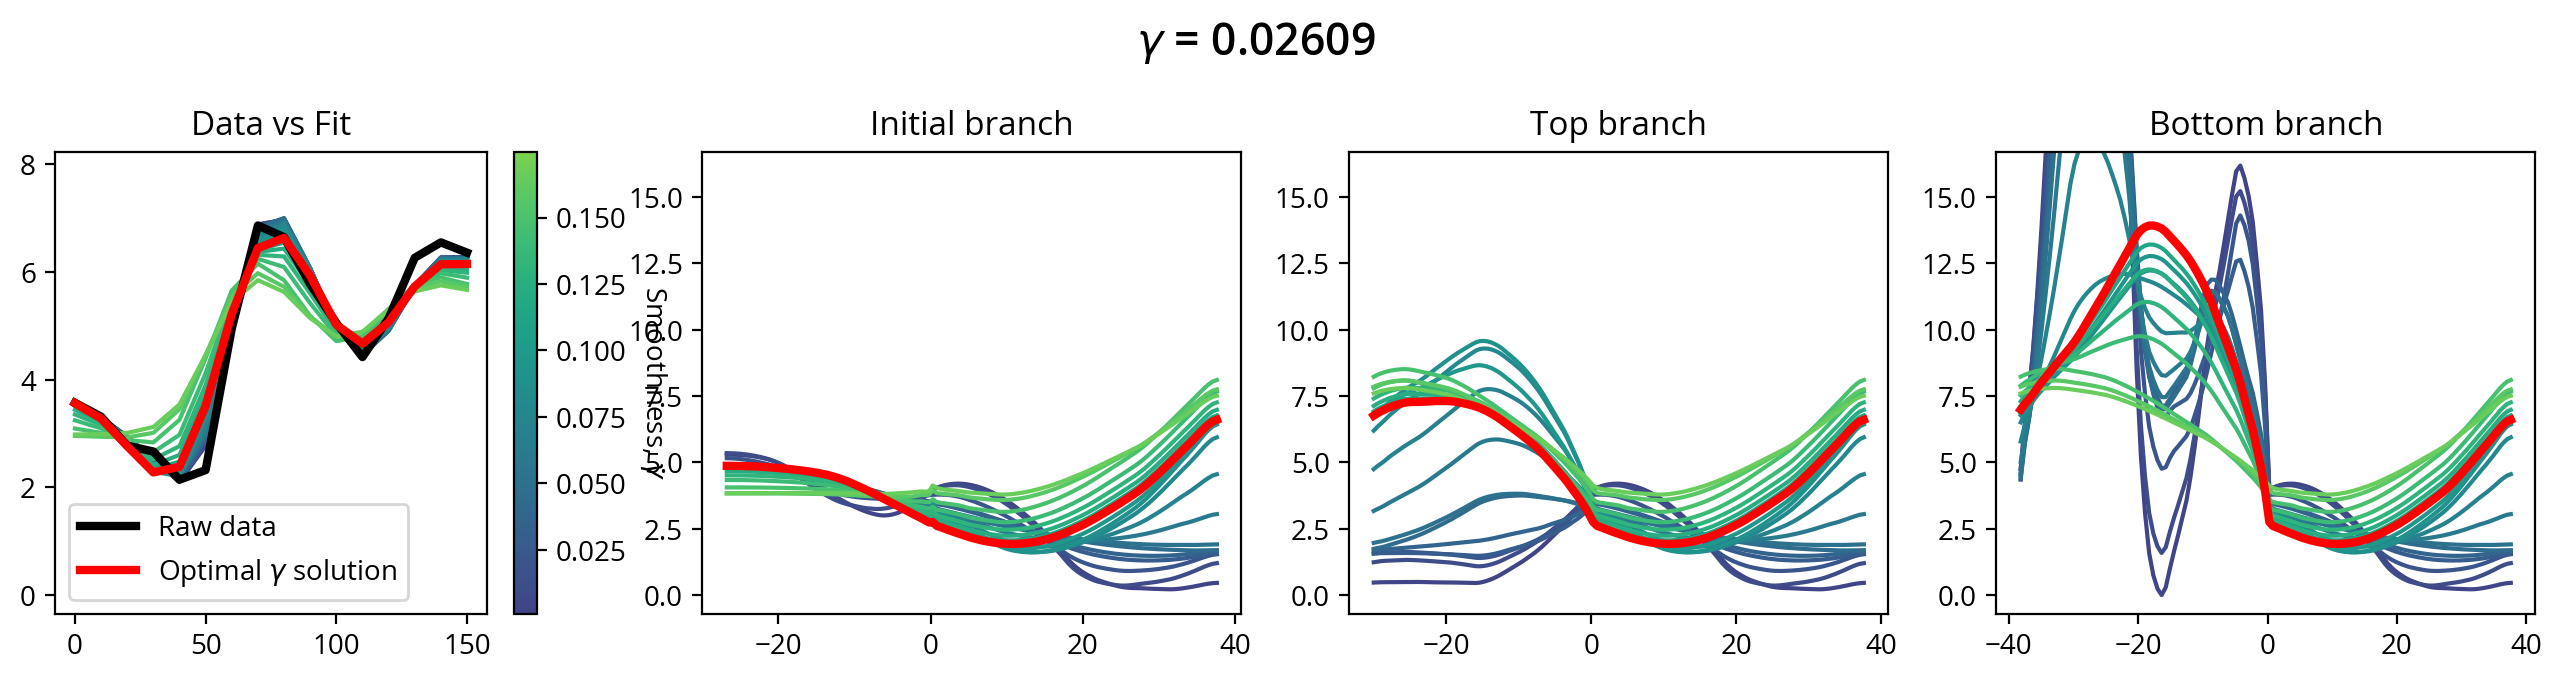

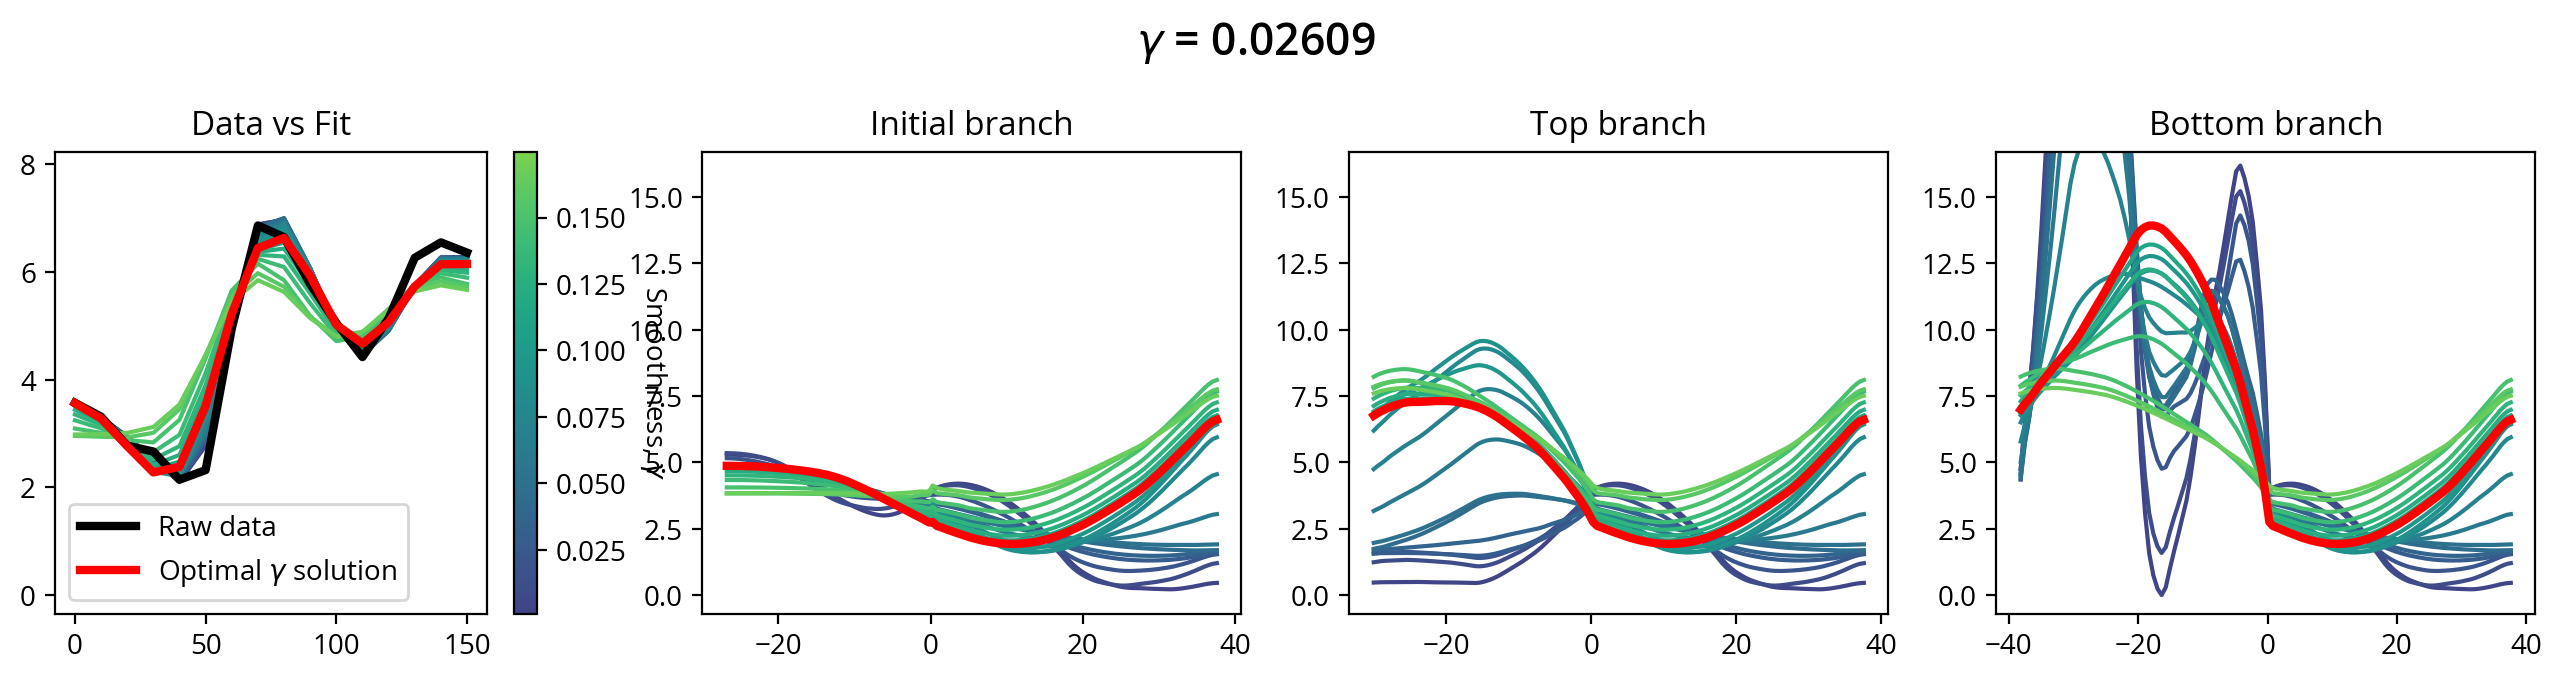

In [254]:
runner.expression_find_gamma.plot_gamma_sweep()

In [255]:
# Last check does the number of indices help?
from src.deconvolution_solver import DeconvolutionSolver
from src.timer import Timer

timer = Timer()

config = runner.expression_find_gamma.deconvolution_solver.config

test_solver = DeconvolutionSolver(config,
    runner.expression_find_gamma.deconvolution_solver.g,
    config.H, 0.026, kappa=0.0, verbose=True)
f = test_solver.deconvolve()

timer.print_time()


Fit norm: 2.462837243867446
Smoothing norm: 223.02877866663775
00:00:00.167


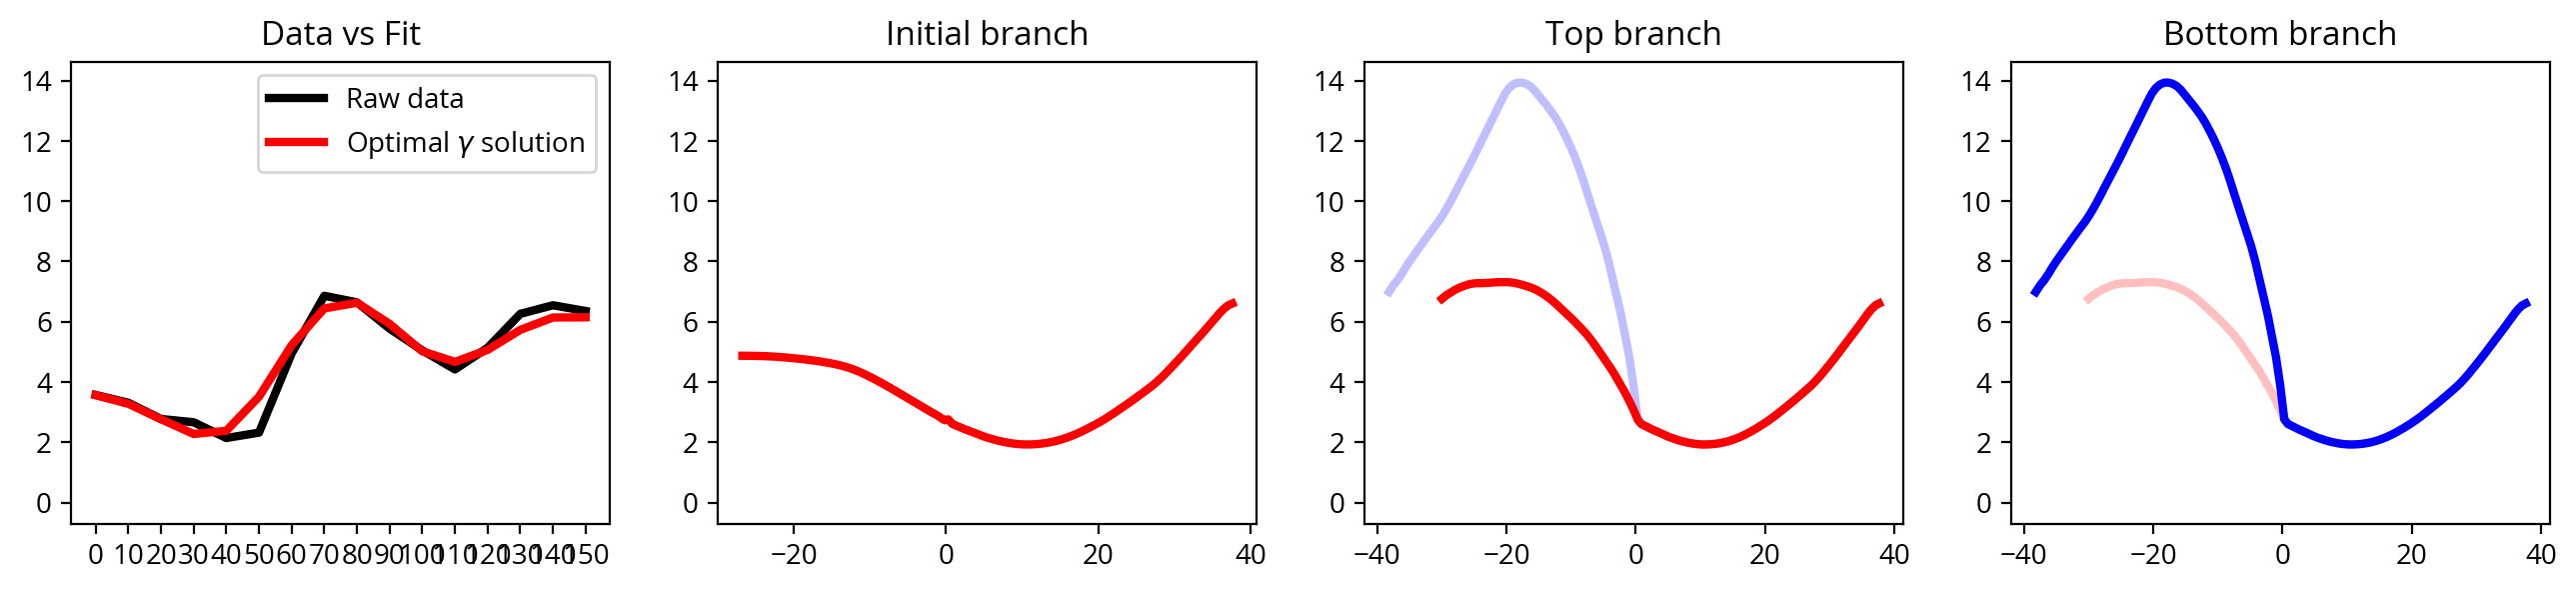

In [256]:
test_solver.plot_fit()